In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv('../data/processed/rq1_features.csv')

In [3]:
SEQ_LEN = 24
FEATURES = [
    'price_lag_1h', 'price_lag_24h', 'price_lag_168h',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'temperature_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation',
    'P_lag_1h', 'P_lag_24h'
]
TARGET = 'Price (EUR/MWhe)'

In [4]:
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 1428, Val: 306, Test: 306


In [5]:
x_scaler = StandardScaler().fit(train_df[FEATURES])
y_scaler = StandardScaler().fit(train_df[[TARGET]])

def make_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(len(X) - seq_len):
        xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(xs), np.array(ys)

def prep(part_df):
    X_scaled = x_scaler.transform(part_df[FEATURES])
    y_scaled = y_scaler.transform(part_df[[TARGET]]).ravel()
    X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN)
    return torch.tensor(X_seq, dtype=torch.float32), torch.tensor(y_seq, dtype=torch.float32)

X_train, y_train = prep(train_df)
X_val, y_val = prep(val_df)
X_test, y_test = prep(test_df)

print(X_train.shape, X_val.shape, X_test.shape)

torch.Size([1404, 24, 13]) torch.Size([282, 24, 13]) torch.Size([282, 24, 13])


In [6]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = LSTMRegressor(n_features=len(FEATURES))

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 100
batch_size = 32
patience = 10

best_val_loss = float('inf')
best_state = None
patience_counter = 0
n = X_train.shape[0]

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(n)
    for i in range(0, n, batch_size):
        idx = perm[i:i + batch_size]
        xb, yb = X_train[idx], y_train[idx]
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = loss_fn(val_pred, y_val).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping на епоха {epoch}")
            break

model.load_state_dict(best_state)

Early stopping на епоха 20


<All keys matched successfully>

In [8]:
def evaluate(X, y_scaled):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X).numpy().reshape(-1, 1)
    pred = y_scaler.inverse_transform(pred_scaled).ravel()
    true = y_scaler.inverse_transform(y_scaled.numpy().reshape(-1, 1)).ravel()
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return mae, rmse, r2, pred, true

train_mae, train_rmse, train_r2, _, _ = evaluate(X_train, y_train)
val_mae, val_rmse, val_r2, _, _ = evaluate(X_val, y_val)
test_mae, test_rmse, test_r2, test_pred, test_true = evaluate(X_test, y_test)

print(f"TRAIN: MAE={train_mae:.2f}, RMSE={train_rmse:.2f}, R2={train_r2*100:.1f}%")
print(f"VAL:   MAE={val_mae:.2f}, RMSE={val_rmse:.2f}, R2={val_r2*100:.1f}%")
print(f"TEST:  MAE={test_mae:.2f}, RMSE={test_rmse:.2f}, R2={test_r2*100:.1f}%")

TRAIN: MAE=6.20, RMSE=8.19, R2=95.7%
VAL:   MAE=12.53, RMSE=20.68, R2=75.3%
TEST:  MAE=18.61, RMSE=28.96, R2=65.2%


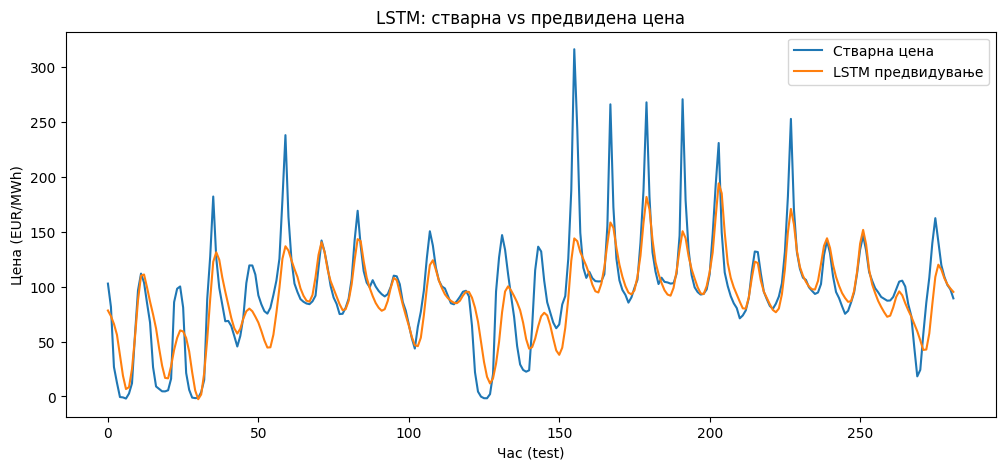

In [9]:
plt.figure(figsize=(12,5))
plt.plot(test_true, label='Стварна цена')
plt.plot(test_pred, label='LSTM предвидување')
plt.legend()
plt.xlabel('Час (test)')
plt.ylabel('Цена (EUR/MWh)')
plt.title('LSTM: стварна vs предвидена цена')
plt.show()

In [10]:
import os
os.makedirs('../results/lstm_model', exist_ok=True)
pd.DataFrame({'y_true': test_true, 'y_pred': test_pred}).to_csv('../results/lstm_model/rq1_price_results.csv', index=False)